In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

df = pd.read_csv('Iris.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [45]:
df['TotalPetal'] = df['PetalLengthCm'] * df['PetalWidthCm']
df['TotalSepal'] = df['SepalLengthCm'] * df['SepalWidthCm']

In [46]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species', 'TotalPetal', 'TotalSepal'],
      dtype='object')

In [47]:
X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'TotalPetal', 'TotalSepal']]
y = df['Species']

<Axes: xlabel='TotalPetal', ylabel='TotalSepal'>

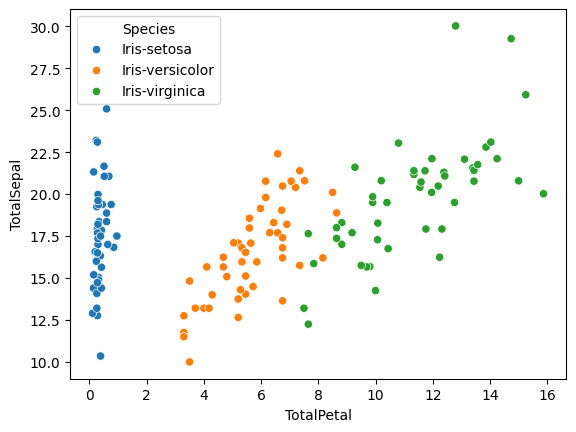

In [48]:
sns.scatterplot(x=df['TotalPetal'], y=df['TotalSepal'], hue=df['Species'])

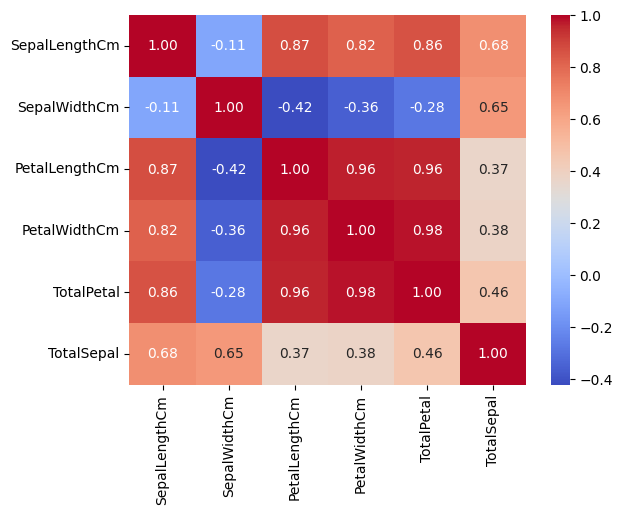

In [49]:
corr = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'TotalPetal', 'TotalSepal']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [52]:
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


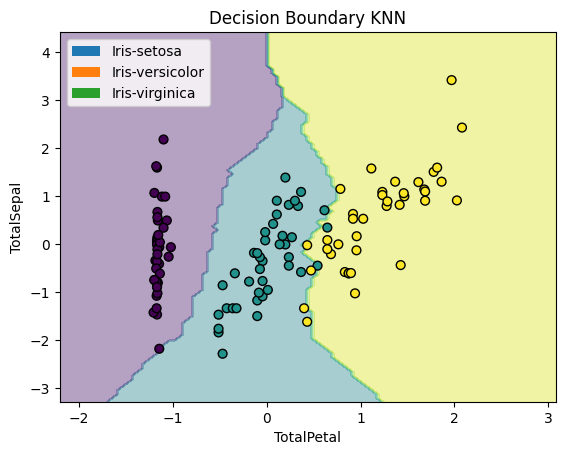

In [56]:
legend_elements = [
    Patch(facecolor='C0', label='Iris-setosa'),
    Patch(facecolor='C1', label='Iris-versicolor'),
    Patch(facecolor='C2', label='Iris-virginica')
]
X2 = df[['TotalPetal', 'TotalSepal']]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)
X_train2_scaled = scaler.fit_transform(X_train2)

knn2 = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn2.fit(X_train2_scaled, y_train2)

disp = DecisionBoundaryDisplay.from_estimator(knn2, X_train2_scaled, response_method='predict', alpha=0.4)

disp.ax_.scatter(X_train2_scaled[:, 0], X_train2_scaled[:, 1], c=pd.factorize(y_train2)[0], edgecolors='k', s=40)
disp.ax_.set_title("Decision Boundary KNN")
disp.ax_.set_xlabel("TotalPetal")
disp.ax_.set_ylabel("TotalSepal")
disp.ax_.legend(handles=legend_elements)
plt.show()

In [54]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species', 'TotalPetal', 'TotalSepal'],
      dtype='object')

In [55]:
sepal_length_cm = float(input('Sepal Length CM: '))
petal_length_cm = float(input('Petal Length CM: '))
petal_width_cm = float(input('Petal Width CM: '))
sepal_width_cm = float(input('Sepal Width CM: '))

X_input = pd.DataFrame([{
    'SepalLengthCm': sepal_length_cm,
    'SepalWidthCm': sepal_width_cm,
    'PetalLengthCm': petal_length_cm,
    'PetalWidthCm': petal_width_cm
}])

X_input['TotalPetal'] = X_input['PetalLengthCm'] * X_input['PetalWidthCm']
X_input['TotalSepal'] = X_input['SepalLengthCm'] * X_input['SepalWidthCm']

X_input_scaled = scaler.fit_transform(X_input)

y_input_pred = knn.predict(X_input_scaled)
print(y_input_pred)

ValueError: could not convert string to float: ''